# Temporal snapshots from the Waddington-OT dataset

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:kantorovich-waddington-ot` from the public iPSC reprogramming data of Schiebinger et al. The figure deliberately shows only observed population snapshots: it does not draw inferred couplings, ancestors, descendants, or interpolated cell trajectories.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (
            base / "notebooks-figures" / "figure_style.py",
            base / "figure_style.py",
        ):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("IPython", "ipython"),
)
_OT4ML_REQUIRED_FILES = (
    "notebooks-figures/assets/waddington_ot_snapshots.npz",
)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
from pathlib import Path
import shutil

from IPython.display import Image as DisplayImage
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np

from figure_style import (
    BLUE,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "kantorovich-waddington-ot"
OUT = figure_dir(NAME)
ASSET = FIGROOT / "assets" / "waddington_ot_snapshots.npz"
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"
ARXIV_OUTPUT = ROOT / "arxiv" / "figures" / f"{NAME}--waddington-ot.pdf"

## Empirical populations at fixed times

Let $z_i\in\mathbb R^2$ denote the released force-layout coordinate of a cell and let $t_i$ be its collection day. At a fixed day $t$, the observed cell population is represented by the empirical measure

$$
\alpha_t=\frac{1}{n_t}\sum_{i:\,t_i=t}\delta_{z_i}.
$$

This differs from representing a *single* cell as a distribution over genes. Here each cell is one atom, and the measure describes a complete population. The compact asset stores a reproducible global sample and all cells observed at days $0$, $9$, and $18$.

In [3]:
def load_snapshot_data(path: Path) -> dict[str, np.ndarray]:
    """Load and validate the compact Waddington-OT snapshot asset.

    Args:
        path: Repository-local compressed NumPy archive.

    Returns:
        Dictionary containing a time-labeled background and three snapshots.

    Raises:
        FileNotFoundError: If the compact asset is unavailable.
        ValueError: If an array has an inconsistent shape or day label.
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing Waddington-OT asset: {path}")
    with np.load(path) as archive:
        data = {name: archive[name] for name in archive.files}

    background = data.get("background")
    background_day = data.get("background_day")
    snapshot_days = data.get("snapshot_days")
    if background is None or background.ndim != 2 or background.shape[1] != 2:
        raise ValueError("background must have shape (n_cells, 2)")
    if background_day is None or background_day.shape != (len(background),):
        raise ValueError("background_day must contain one day per background cell")
    if snapshot_days is None or snapshot_days.shape != (3,):
        raise ValueError("snapshot_days must contain exactly three days")
    for index, day in enumerate(snapshot_days):
        snapshot = data.get(f"snapshot_{index}")
        if snapshot is None or snapshot.ndim != 2 or snapshot.shape[1] != 2:
            raise ValueError(f"snapshot_{index} must have shape (n_cells, 2)")
        if len(snapshot) == 0:
            raise ValueError(f"snapshot at day {float(day):g} is empty")
    return data


data = load_snapshot_data(ASSET)
print(
    f"{len(data['background']):,} cells in the aggregate sample; "
    + ", ".join(
        f"{len(data[f'snapshot_{index}']):,} cells at day {day:g}"
        for index, day in enumerate(data["snapshot_days"])
    )
)

40,000 cells in the aggregate sample; 4,556 cells at day 0, 5,016 cells at day 9, 7,436 cells at day 18


## A common display geometry

The force-layout embedding (FLE) is a nonlinear two-dimensional visualization built from the full time course. It supplies a common coordinate system for the four panels, but distances and straight segments in this display should not be interpreted as biological trajectories. Fixing identical limits in every panel makes the population displacement and branching visible without visually rescaling individual snapshots.

In [4]:
def common_limits(
    dataset: dict[str, np.ndarray],
    *,
    quantile: float = 0.002,
    padding: float = 0.035,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Compute robust common limits for every panel.

    Args:
        dataset: Validated snapshot asset.
        quantile: Tail fraction removed on each side of each coordinate.
        padding: Extra fraction of the retained coordinate span.

    Returns:
        Horizontal and vertical plotting limits.
    """
    points = np.vstack(
        [dataset["background"]]
        + [dataset[f"snapshot_{index}"] for index in range(3)]
    )
    lower = np.quantile(points, quantile, axis=0)
    upper = np.quantile(points, 1.0 - quantile, axis=0)
    margin = padding * np.maximum(upper - lower, np.finfo(float).eps)
    lower -= margin
    upper += margin
    return (lower[0], upper[0]), (lower[1], upper[1])


def draw_gray_landscape(ax: plt.Axes, points: np.ndarray) -> None:
    """Render the common context cloud behind one highlighted snapshot.

    Args:
        ax: Matplotlib axes receiving the point cloud.
        points: Background FLE coordinates of shape ``(n_cells, 2)``.
    """
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=0.32,
        color=LIGHT_GRAY,
        alpha=0.20,
        linewidths=0,
        rasterized=True,
        zorder=0,
    )


def draw_time_key(ax: plt.Axes, color_map: LinearSegmentedColormap) -> None:
    """Draw a compact red-to-blue time key inside the aggregate panel."""
    positions = np.linspace(0.08, 0.92, 80)
    for index in range(len(positions) - 1):
        ax.plot(
            positions[index : index + 2],
            [0.045, 0.045],
            color=color_map(index / (len(positions) - 2)),
            linewidth=2.2,
            solid_capstyle="butt",
            transform=ax.transAxes,
            clip_on=False,
            zorder=5,
        )
    ax.text(0.08, 0.075, "day 0", color=RED, fontsize=6.4, transform=ax.transAxes)
    ax.text(
        0.92,
        0.075,
        "day 18",
        color=BLUE,
        fontsize=6.4,
        ha="right",
        transform=ax.transAxes,
    )

## Four-panel rendering

The first panel aggregates cells from all collection times and uses a continuous red-to-blue time scale. Each remaining panel highlights one observed empirical population $\alpha_t$ over the same lightly rendered global landscape. This separates observed temporal change from the transport couplings that Waddington-OT subsequently infers.

In [5]:
def render_figure(dataset: dict[str, np.ndarray]) -> plt.Figure:
    """Render the aggregate landscape and three observed populations.

    Args:
        dataset: Validated compact Waddington-OT snapshot asset.

    Returns:
        Complete four-panel Matplotlib figure.
    """
    figure, axes = plt.subplots(1, 4, figsize=(7.50, 1.92))
    x_limits, y_limits = common_limits(dataset)
    color_map = LinearSegmentedColormap.from_list(
        "ot4ml_time",
        [RED, VIOLET, BLUE],
    )
    day_normalization = Normalize(
        vmin=float(dataset["snapshot_days"].min()),
        vmax=float(dataset["snapshot_days"].max()),
    )

    for axis in axes:
        axis.set_xlim(*x_limits)
        axis.set_ylim(*y_limits)
        axis.set_aspect("equal", adjustable="box")
        remove_axes(axis)

    background = dataset["background"]
    axes[0].scatter(
        background[:, 0],
        background[:, 1],
        s=0.48,
        c=dataset["background_day"],
        cmap=color_map,
        norm=day_normalization,
        alpha=0.55,
        linewidths=0,
        rasterized=True,
    )
    draw_time_key(axes[0], color_map)

    for panel_index, (axis, day) in enumerate(
        zip(axes[1:], dataset["snapshot_days"], strict=True)
    ):
        draw_gray_landscape(axis, background)
        snapshot = dataset[f"snapshot_{panel_index}"]
        axis.scatter(
            snapshot[:, 0],
            snapshot[:, 1],
            s=1.05,
            color=color_map(day_normalization(float(day))),
            alpha=0.72,
            linewidths=0,
            rasterized=True,
            zorder=2,
        )

    titles = ("all collection days",) + tuple(
        f"day {day:g}" for day in dataset["snapshot_days"]
    )
    for axis, title in zip(axes, titles, strict=True):
        axis.set_title(title, fontsize=8.0, pad=2.2)
    figure.subplots_adjust(
        left=0.004,
        right=0.996,
        bottom=0.012,
        top=0.89,
        wspace=0.035,
    )
    return figure


figure = render_figure(data)
output_path = OUT / "waddington-ot.pdf"
save_pdf(figure, output_path, pad_inches=0.015)
ARXIV_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(output_path, ARXIV_OUTPUT)
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(
    THUMBNAIL,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.015,
    facecolor="white",
)
plt.close(figure)
print(f"Saved {output_path}")

Saved /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/kantorovich-waddington-ot/waddington-ot.pdf


## Figure preview

The vector PDF included in the manuscript uses rasterized point layers to remain compact while preserving crisp labels. The same viewport across all panels is essential: apparent movement comes from the changing empirical populations, not from panel-wise rescaling.

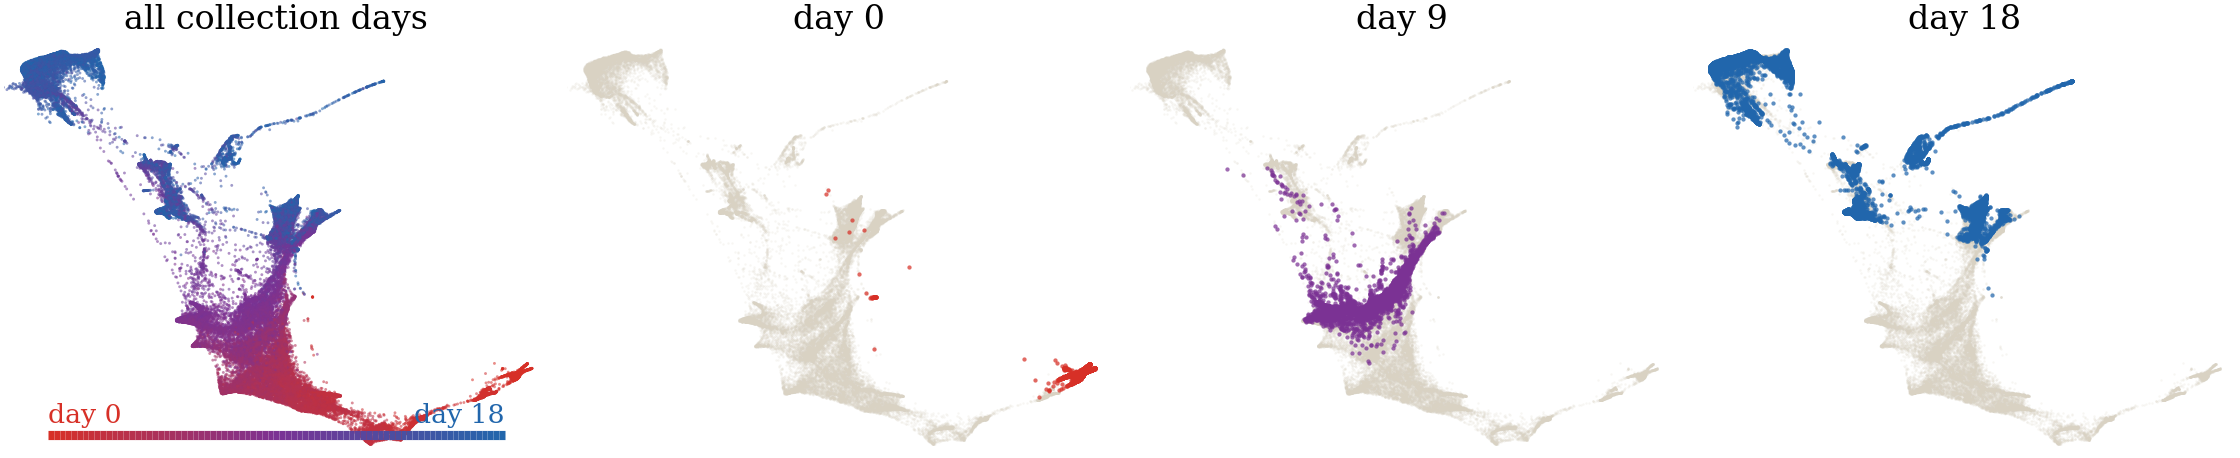

In [6]:
display(DisplayImage(filename=str(THUMBNAIL), width=1100))